# 02 — Serial vs Parallel Simulation

This notebook compares the serial and parallel Monte Carlo implementations:
- Running a single serial assignment
- Running multiple trials serially vs with `Threads.@threads`
- Verifying correctness (both modes should produce statistically equivalent results)
- A first look at wall-clock speedup

In [2]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.instantiate()

include("../src/types.jl")
include("../src/generate_data.jl")
include("../src/serial_sim.jl")
include("../src/parallel_sim.jl")
include("../src/monte_carlo.jl")

using Statistics, Plots
println("Julia threads: ", Threads.nthreads())

  Activating project at `~/Documents/MIT/18.337/parallel-school-assignment-sim`


Julia threads: 8


## 1. Generate Scenario

In [3]:
students, schools = generate_scenario(; seed = 42)
println("Students: ", length(students), "  Schools: ", length(schools))

Students: 10000  Schools: 20


## 2. Single Serial Run

In [4]:
result = run_serial(students, schools)

println("First-choice rate : ", round(result.first_choice_rate * 100; digits=2), "%")
println("Unassigned        : ", result.unassigned_count)
println("Rank distribution : ", result.rank_distribution)

First-choice rate : 90.76%
Unassigned        : 5
Rank distribution : [9076, 674, 188, 48, 9]


## 3. Monte Carlo — Serial vs Parallel

In [5]:
N_TRIALS = 50

t_serial_start = time()
serial_summaries = run_monte_carlo(students, schools, N_TRIALS; parallel = false, seed = 1)
t_serial = time() - t_serial_start

t_parallel_start = time()
parallel_summaries = run_monte_carlo(students, schools, N_TRIALS; parallel = true, seed = 1)
t_parallel = time() - t_parallel_start

@printf "Serial   MC : %.3f s\n" t_serial
@printf "Parallel MC : %.3f s\n" t_parallel
@printf "Speedup     : %.2fx\n"  t_serial / t_parallel

Serial   MC : 0.211 s
Parallel MC : 0.027 s
Speedup     : 7.85x


## 4. Are Results Statistically Equivalent?

In [6]:
serial_agg   = aggregate_results(serial_summaries)
parallel_agg = aggregate_results(parallel_summaries)

println("Serial   mean first-choice rate : ", round(serial_agg.mean_first_choice_rate * 100; digits=2), "%")
println("Parallel mean first-choice rate : ", round(parallel_agg.mean_first_choice_rate * 100; digits=2), "%")

# Both should be close (different seeds → slightly different means, but same distribution)
abs_diff = abs(serial_agg.mean_first_choice_rate - parallel_agg.mean_first_choice_rate)
println("Absolute difference             : ", round(abs_diff * 100; digits=3), "%  (expected <1%)")

Serial   mean first-choice rate : 90.76%
Parallel mean first-choice rate : 90.79%
Absolute difference             : 0.025%  (expected <1%)


## 5. First-Choice Rate Distribution

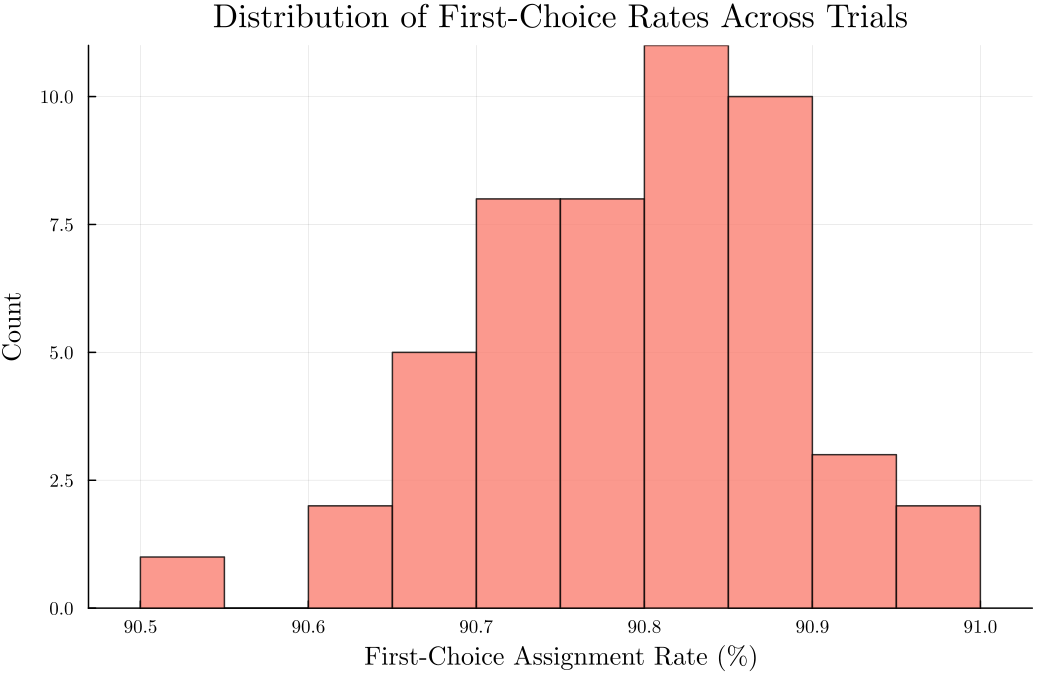

In [7]:
include("../src/plots.jl")
plot_first_choice_distribution(parallel_summaries)